## import necessary libraries 

In [145]:
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Train-Test Split
from sklearn.model_selection import train_test_split

# Regression Models
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.tree import plot_tree

# Evaluation Metrics
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

In [146]:
df=pd.read_csv("Boston_clean.csv")

In [147]:
df

,ID,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,1,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,2,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,4,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
3,5,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
4,7,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,12.43,22.9
...,...,...,...,...,...,...,...,...,...,...,...,...
328,500,9.69,0,0.585,5.569,73.5,2.3999,6,391,19.2,15.10,17.5
329,502,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,9.67,22.4
330,503,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,9.08,20.6
331,504,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,5.64,23.9


In [148]:
df.shape

(333, 12)

In [149]:
df.head()

,ID,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,1,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,2,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,4,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
3,5,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
4,7,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,12.43,22.9


In [150]:
df.describe()

,ID,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
count,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000,333.000000
mean,250.951952,11.293483,0.060060,0.557144,6.265619,68.226426,3.709934,9.633634,409.279279,18.448048,12.515435,22.768769
std,147.859438,6.998123,0.237956,0.114955,0.703952,28.133344,1.981123,8.742174,170.841988,2.151821,7.067781,9.173468
min,1.000000,0.740000,0.000000,0.385000,3.561000,6.000000,1.129600,1.000000,188.000000,12.600000,1.730000,5.000000
25%,123.000000,5.130000,0.000000,0.453000,5.884000,45.400000,2.122400,4.000000,279.000000,17.400000,7.180000,17.400000
50%,244.000000,9.900000,0.000000,0.538000,6.202000,76.700000,3.092300,5.000000,330.000000,19.000000,10.970000,21.600000
75%,377.000000,18.100000,0.000000,0.631000,6.595000,93.800000,5.116700,24.000000,666.000000,20.200000,16.420000,25.000000
max,506.000000,27.740000,1.000000,0.871000,8.725000,100.000000,10.710300,24.000000,711.000000,21.200000,37.970000,50.000000


In [151]:
df.corr(numeric_only=True)

,ID,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
ID,1.000000,0.421978,0.007958,0.440185,-0.112790,0.257300,-0.356461,0.707526,0.686246,0.309838,0.281953,-0.221694
indus,0.421978,1.000000,0.037496,0.750087,-0.440365,0.638378,-0.702327,0.569779,0.708313,0.391087,0.614155,-0.473932
chas,0.007958,0.037496,1.000000,0.080275,0.112251,0.068286,-0.081834,0.007714,-0.021826,-0.125067,-0.050055,0.204390
nox,0.440185,0.750087,0.080275,1.000000,-0.338515,0.736000,-0.769364,0.612180,0.670722,0.192513,0.598874,-0.413054
rm,-0.112790,-0.440365,0.112251,-0.338515,1.000000,-0.248573,0.269191,-0.272783,-0.356987,-0.366927,-0.615747,0.689598
age,0.257300,0.638378,0.068286,0.736000,-0.248573,1.000000,-0.764208,0.447380,0.511893,0.259293,0.588834,-0.358888
dis,-0.356461,-0.702327,-0.081834,-0.769364,0.269191,-0.764208,1.000000,-0.477610,-0.529539,-0.231101,-0.505939,0.249422
rad,0.707526,0.569779,0.007714,0.612180,-0.272783,0.447380,-0.477610,1.000000,0.903562,0.470849,0.484568,-0.352251
tax,0.686246,0.708313,-0.021826,0.670722,-0.356987,0.511893,-0.529539,0.903562,1.000000,0.467437,0.544485,-0.448078
ptratio,0.309838,0.391087,-0.125067,0.192513,-0.366927,0.259293,-0.231101,0.470849,0.467437,1.000000,0.374802,-0.481376


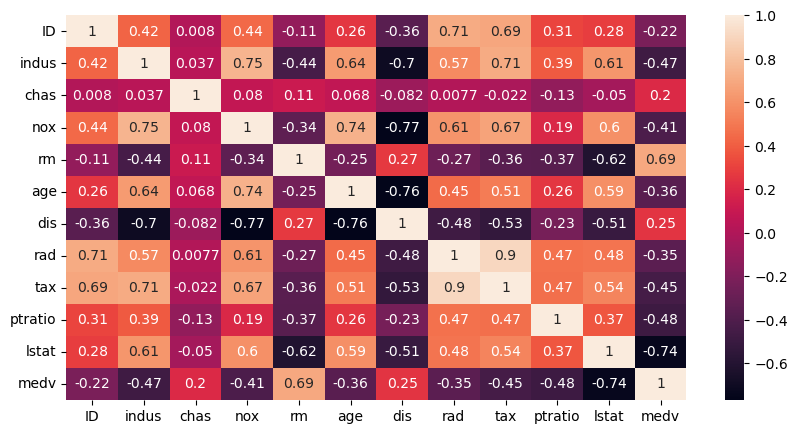

In [152]:
plt.figure(figsize=(10,5))
sns.heatmap(df.corr(numeric_only=True),annot=True)
plt.show()

In [153]:
x=df.drop(columns='medv')
x.head()

,ID,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat
0,1,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98
1,2,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14
2,4,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94
3,5,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33
4,7,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,12.43


In [154]:
y=df['medv']
y.head()

0    24.0
1    21.6
2    33.4
3    36.2
4    22.9
Name: medv, dtype: float64

### SPLITTING DATA FOR TRAINING AND TESTING 

In [155]:
X_train,X_test,Y_train,Y_test=train_test_split(x,y,test_size=0.2)

In [156]:
X_train.shape,X_test.shape,Y_train.shape,Y_test.shape

((266, 11), (67, 11), (266,), (67,))

### Decission Regressor()

In [157]:
dt=DecisionTreeRegressor()

In [158]:
dt

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [159]:
dt.fit(X_train,Y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


### Testing 

In [160]:
Y_pred=dt.predict(X_test)

In [161]:
Y_pred

array([ 7.4, 10.4, 33.4, 21.4, 15.6, 20.7, 18.5, 17.2, 29.9, 17.7, 25. ,
       21.4, 27.9, 17.4, 37.6, 23.8,  7.2, 31.1, 20.6, 17.6, 19.7, 19.4,
       21.7, 25.3, 24.4,  9.5, 37.6, 22.2, 11.7,  7.2, 37.6, 23.8, 16.2,
       23.9, 30.3, 23.3, 18.6, 25. , 21.2, 36.1, 20.6, 36.4, 14.9, 12.6,
       33.1, 37.6, 29. , 27.9, 37.6, 21.4, 30.5, 13.6, 20.7,  8.8, 19.3,
       22.7, 23.5, 24.6, 16.2, 12.7, 13.5, 16.1, 29. , 30.5, 27.9, 12.6,
       21.8])

In [162]:
mae = mean_absolute_error(Y_test, Y_pred)
mse = mean_squared_error(Y_test,Y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(Y_test,Y_pred)


print('Mean Absolute Error:-',mae)
print('Mean Squared Error:-',mse)
print('Root Mean Squared Error:-',rmse)
print('R2 score:-',r2)

Mean Absolute Error:- 4.7253731343283585
Mean Squared Error:- 47.09761194029851
Root Mean Squared Error:- 6.8627699903390695
R2 score:- 0.6199729607471395


### CREATING DATAFRAME

In [163]:
evaluation = pd.DataFrame({
    "Metric":["MAE","MSE","RMSE","R2 Score"],
    "Value":[mae,mse,rmse,r2]
})

evaluation

,Metric,Value
0,MAE,4.725373
1,MSE,47.097612
2,RMSE,6.862770
3,R2 Score,0.619973


### COMPARISION BETWEEN Y_TEST & Y_PRED

In [164]:
comparison = pd.DataFrame({
    "Actual":Y_test,
    "Predicted":Y_pred
})

comparison.head(20)

,Actual,Predicted
261,5.0,7.4
282,8.7,10.4
3,36.2,33.4
275,10.9,21.4
71,19.5,15.6
123,24.6,20.7
78,19.2,18.5
253,8.8,17.2
131,32.0,29.9
310,23.2,17.7


#### CHECKING ERRORS

In [165]:
comparison['Error'] = comparison['Actual']-comparison['Predicted']

In [166]:
comparison.head(20)

,Actual,Predicted,Error
261,5.0,7.4,-2.4
282,8.7,10.4,-1.7
3,36.2,33.4,2.8
275,10.9,21.4,-10.5
71,19.5,15.6,3.9
123,24.6,20.7,3.9
78,19.2,18.5,0.7
253,8.8,17.2,-8.4
131,32.0,29.9,2.1
310,23.2,17.7,5.5


In [167]:
comparison['Error'].max()

25.0

In [168]:
comparison['Error'].min()

-10.499999999999998

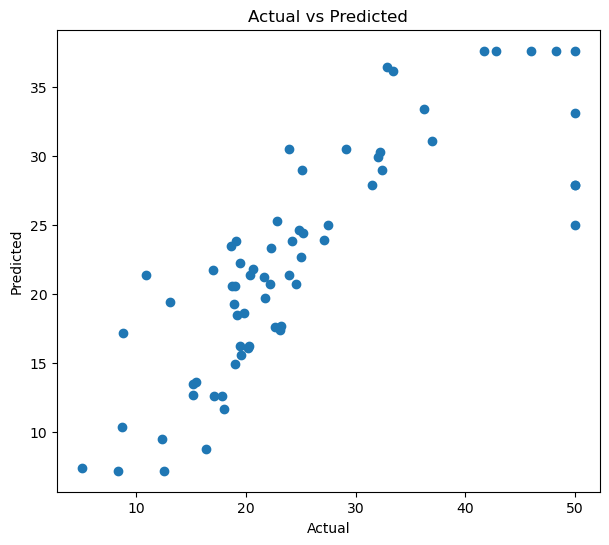

In [169]:
plt.figure(figsize=(7,6))

plt.scatter(Y_test,Y_pred)
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.title("Actual vs Predicted")
plt.show()

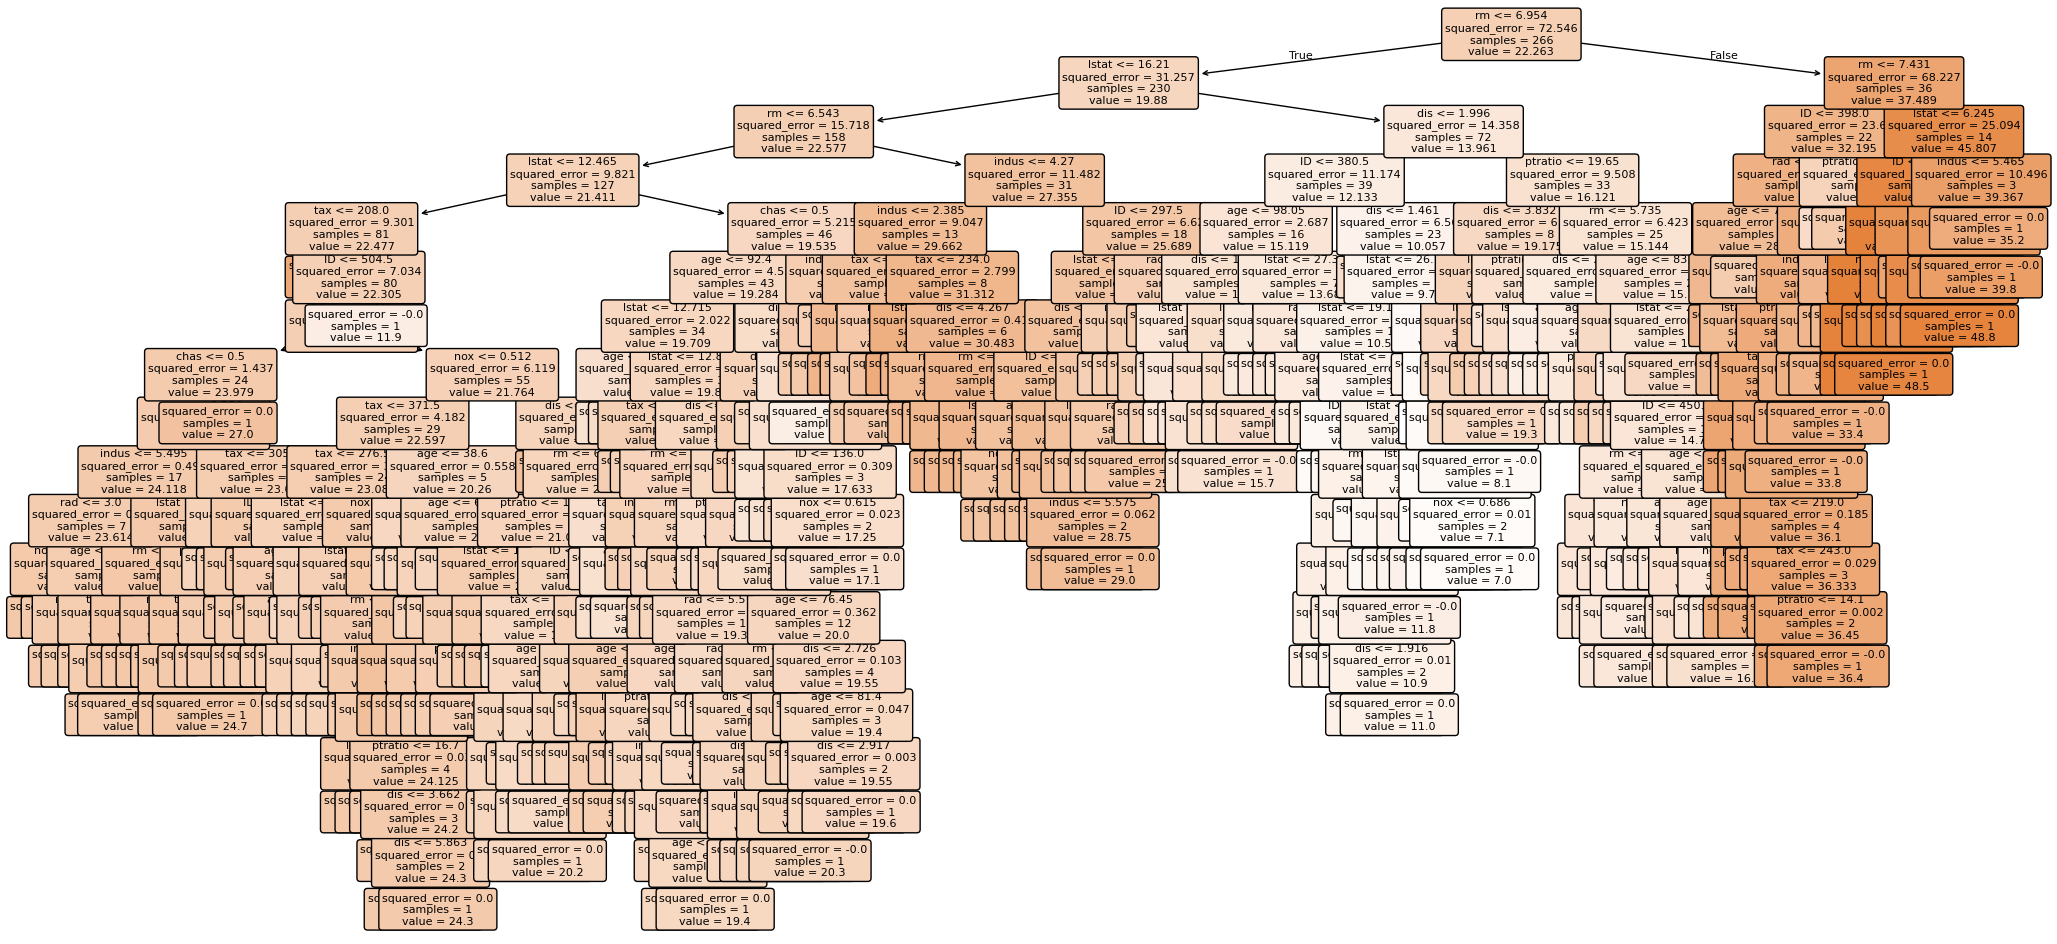

In [170]:
plt.figure(figsize=(25,12))
plot_tree(dt,feature_names=x.columns,filled=True,rounded=True,fontsize=8)
plt.show()

In [171]:
dt.feature_importances_

array([0.04355309, 0.01207903, 0.00264708, 0.00893498, 0.63470837,
       0.0081481 , 0.02847819, 0.00564215, 0.01749738, 0.00808582,
       0.23022581])

### HyperParameterTuning

In [172]:
params = {
    "criterion":[
        "squared_error",
        "absolute_error"
    ],
    "max_depth":[
        3,5,7,10,None
    ],
    "min_samples_split":[
        2,5,10,20
    ],
    "min_samples_leaf":[
        1,2,4,6
    ],
    "max_features":[
        None,
        "sqrt",
        "log2"
    ]
}

In [173]:
grid = GridSearchCV(
    estimator=DecisionTreeRegressor(random_state=42),
    param_grid=params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

In [174]:
grid.fit(X_train,Y_train)

,estimator,DecisionTreeR...ndom_state=42)
,param_grid,"{'criterion': ['squared_error', 'absolute_error'], 'max_depth': [3, 5, ...], 'max_features': [None, 'sqrt', ...], 'min_samples_leaf': [1, 2, ...], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,criterion,'squared_error'


In [175]:
grid.best_params_

{'criterion': 'squared_error',
 'max_depth': 5,
 'max_features': None,
 'min_samples_leaf': 2,
 'min_samples_split': 10}

In [176]:
best_tree = grid.best_estimator_

In [177]:
pred = best_tree.predict(X_test)

In [178]:
print("MAE :",mean_absolute_error(Y_test,pred))

print('MSE:',mean_squared_error(Y_test,pred))

print("RMSE :",np.sqrt(mean_squared_error(Y_test,pred)))

print("R2 :",r2_score(Y_test,pred))

MAE : 4.163505249840919
MSE: 48.86636549670594
RMSE : 6.990448161363186
R2 : 0.6057010231792319


### TRAINING

In [179]:
y_pred_train = dt.predict(X_train)

In [180]:
r2_train = r2_score(Y_train, y_pred_train)
r2_train

1.0

In [181]:
print("MAE :",mean_absolute_error(Y_test,pred))

print("RMSE :",np.sqrt(mean_squared_error(Y_test,pred)))

print("R2 :",r2_score(Y_test,pred))

MAE : 4.163505249840919
RMSE : 6.990448161363186
R2 : 0.6057010231792319


In [182]:
dt_2 = DecisionTreeRegressor(max_depth = 5)

In [183]:
dt_2.fit(X_train,Y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [184]:
y_pred_train = dt_2.predict(X_train)

r2_train_ = r2_score(Y_train,y_pred_train)
r2_train_

0.9359801973847273

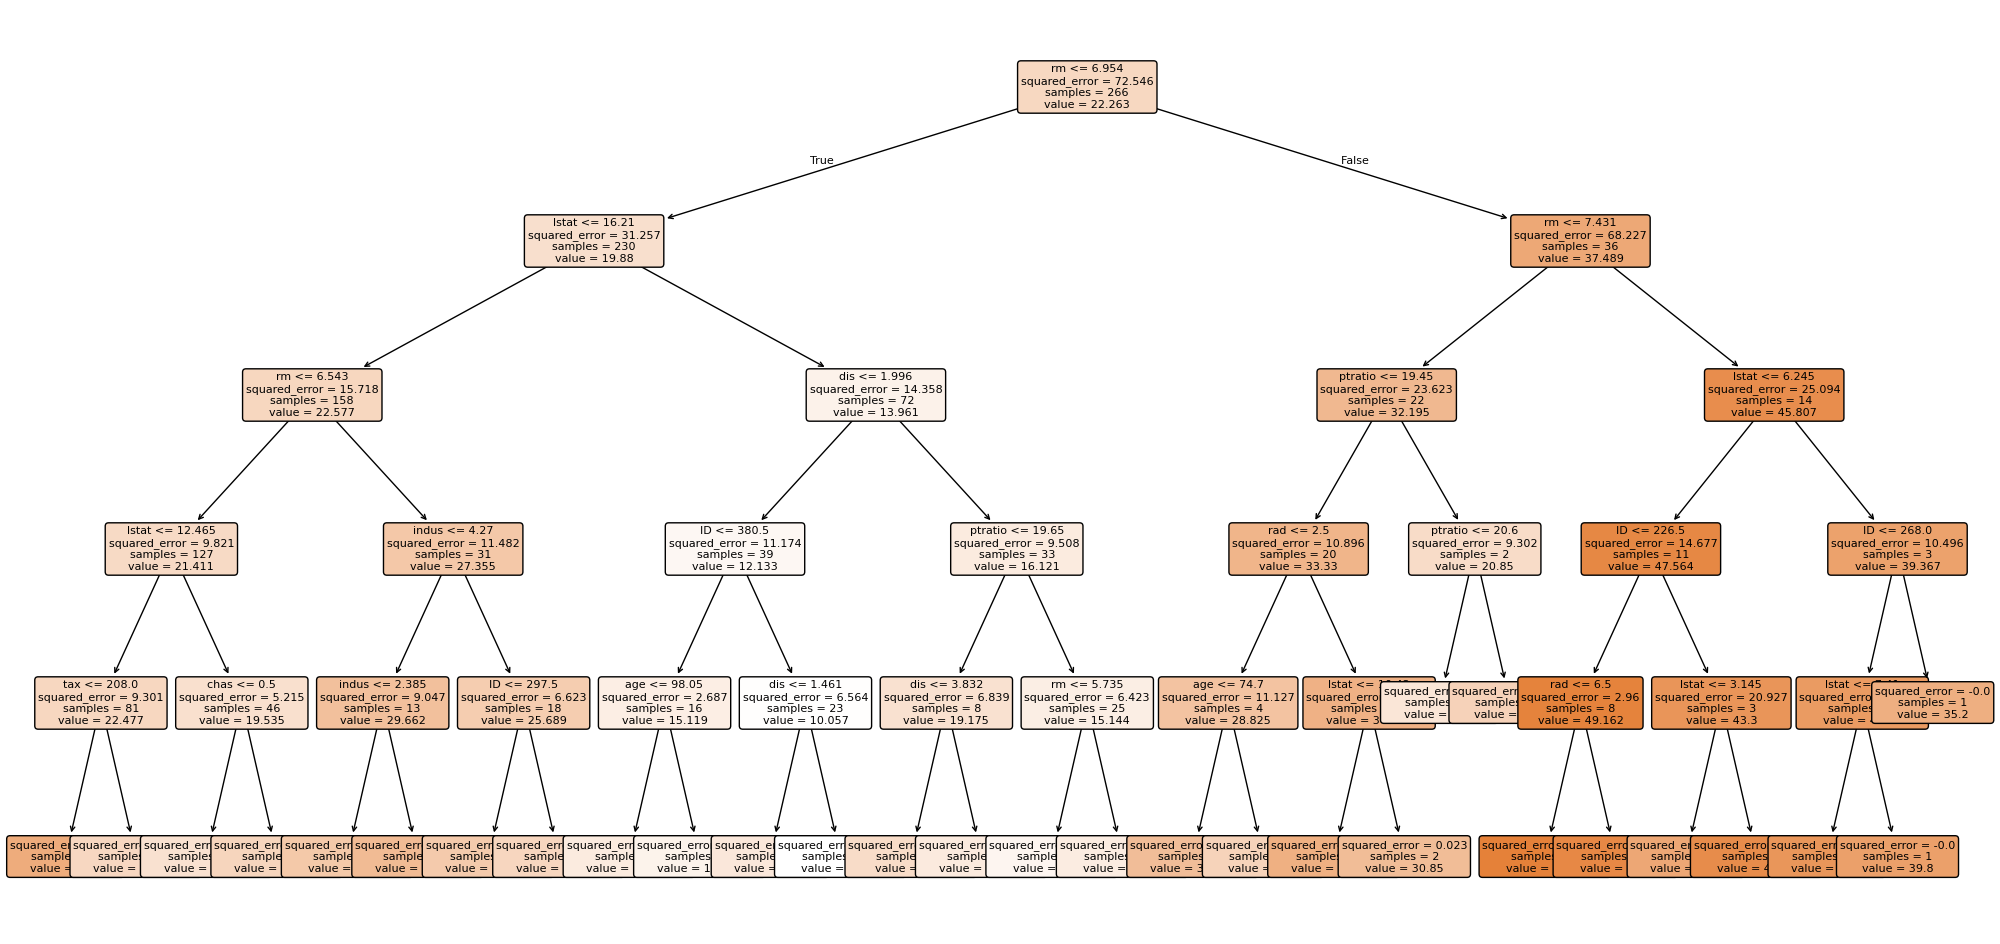

In [185]:
plt.figure(figsize=(25,12))
plot_tree(dt_2,feature_names=x.columns,filled=True,rounded=True,fontsize=8)
plt.show()

### KNN

In [186]:
KNN = KNeighborsRegressor(n_neighbors=3)

In [187]:
KNN.fit(X_train,Y_train)

,n_neighbors,3
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [188]:
#checking testing accuracy
y_pred_test = KNN.predict(X_test)
mae_knn = mean_absolute_error(Y_test, y_pred_test)
mse_knn = mean_squared_error(Y_test, y_pred_test)
rmse_knn = mse_knn**0.5
r2_knn = r2_score(Y_test, y_pred_test)

print("MAE",mae_knn)
print("MSE",mse_knn)
print("RMSE",rmse_knn)
print("r2 score",r2_knn)

MAE 4.850248756218906
MSE 74.13265339966831
RMSE 8.610032136970704
r2 score 0.401829272805888


### HyperParameterTuning

In [189]:
params = {
    "n_neighbors": [3, 5, 7, 9, 11],
    "weights": ["uniform", "distance"],
    "algorithm": ["auto", "ball_tree", "kd_tree", "brute"],
    "leaf_size": [20, 30, 40],
    "p": [1, 2]
}

In [190]:
grid = GridSearchCV(
    estimator=KNeighborsRegressor(),
    param_grid=params,
    cv=5,
    scoring="r2",
    n_jobs=-1
)

In [191]:
grid.fit(X_train,Y_train)

,estimator,KNeighborsRegressor()
,param_grid,"{'algorithm': ['auto', 'ball_tree', ...], 'leaf_size': [20, 30, ...], 'n_neighbors': [3, 5, ...], 'p': [1, 2], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_neighbors,9


In [192]:
grid.best_params_

{'algorithm': 'auto',
 'leaf_size': 20,
 'n_neighbors': 9,
 'p': 1,
 'weights': 'distance'}

In [193]:
best_knn=grid.best_estimator_

In [194]:
pred=best_knn.predict(X_test)

In [195]:
print("MAE :",mean_absolute_error(Y_test,pred))

print('MSE:',mean_squared_error(Y_test,pred))

print("RMSE :",np.sqrt(mean_squared_error(Y_test,pred)))

print("R2 :",r2_score(Y_test,pred))

MAE : 5.104240916149979
MSE: 82.3433536387449
RMSE : 9.0743238667542
R2 : 0.3355777586950591


In [196]:
pred=best_knn.predict(X_train)

In [197]:
print("MAE :",mean_absolute_error(Y_train,pred))

print('MSE:',mean_squared_error(Y_train,pred))

print("RMSE :",np.sqrt(mean_squared_error(Y_train,pred)))

print("R2 :",r2_score(Y_train,pred))

MAE : 0.0
MSE: 0.0
RMSE : 0.0
R2 : 1.0


### RANDOMFORESTREGRESSOR

In [198]:
RFR=RandomForestRegressor()

In [199]:
RFR.fit(X_train,Y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [200]:
y_pred_train_rfr = RFR.predict(X_train)

print("MAE :",mean_absolute_error(Y_train, y_pred_train_rfr))

print('MSE:',mean_squared_error(Y_train, y_pred_train_rfr))

print("RMSE :",np.sqrt(mean_squared_error(Y_train, y_pred_train_rfr)))

print("R2 :",r2_score(Y_train, y_pred_train_rfr))

MAE : 0.7945639097744356
MSE: 1.3924092105263146
RMSE : 1.1800039027589335
R2 : 0.9808064967869076


In [201]:
#checking testing accuracy
y_pred_test = RFR.predict(X_test)
mae_rfr = mean_absolute_error(Y_test, y_pred_test)
mse_rfr = mean_squared_error(Y_test, y_pred_test)
rmse_rfr = mse_rfr**0.5
r2_rfr = r2_score(Y_test, y_pred_test)

print("MAE",mae_rfr)
print("MSE",mse_rfr)
print("RMSE",rmse_rfr)
print("r2 score",r2_rfr)

MAE 3.5701194029850725
MSE 45.2784930447761
RMSE 6.728929561585267
r2 score 0.6346512923956875


### HyperParameterTuning RFR

In [202]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

rfr = RandomForestRegressor(random_state=42)

param_grid = {
    'n_estimators': [100, 200, 300],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': [1.0, 'sqrt']
}

grid = GridSearchCV(
    estimator=rfr,
    param_grid=param_grid,
    cv=5,
    scoring='r2',
    n_jobs=-1
)

grid.fit(X_train, Y_train)

,estimator,RandomForestR...ndom_state=42)
,param_grid,"{'max_depth': [None, 10, ...], 'max_features': [1.0, 'sqrt'], 'min_samples_leaf': [1, 2], 'min_samples_split': [2, 5], ...}"
,scoring,'r2'
,n_jobs,-1
,refit,True
,cv,5
,verbose,0
,pre_dispatch,'2*n_jobs'
,error_score,nan
,return_train_score,False
,n_estimators,200


In [203]:
grid.best_params_

{'max_depth': 20,
 'max_features': 'sqrt',
 'min_samples_leaf': 1,
 'min_samples_split': 2,
 'n_estimators': 200}

In [204]:
best_rfr=grid.best_estimator_

In [205]:
pred=best_rfr.predict(X_test)

In [206]:
print("MAE :",mean_absolute_error(Y_test,pred))

print('MSE:',mean_squared_error(Y_test,pred))

print("RMSE :",np.sqrt(mean_squared_error(Y_test,pred)))

print("R2 :",r2_score(Y_test,pred))

MAE : 3.527388059701493
MSE: 46.25977164925373
RMSE : 6.801453642366
R2 : 0.626733430164912


In [207]:
import pickle

with open("Boston_Project_Model.pkl", "rb") as file:
    RFR = pickle.load(file)

In [208]:
df.head(26)

,ID,indus,chas,nox,rm,age,dis,rad,tax,ptratio,lstat,medv
0,1,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,4.98,24.0
1,2,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,9.14,21.6
2,4,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,2.94,33.4
3,5,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,5.33,36.2
4,7,7.87,0,0.524,6.012,66.6,5.5605,5,311,15.2,12.43,22.9
5,11,7.87,0,0.524,6.377,94.3,6.3467,5,311,15.2,20.45,15.0
6,12,7.87,0,0.524,6.009,82.9,6.2267,5,311,15.2,13.27,18.9
7,13,7.87,0,0.524,5.889,39.0,5.4509,5,311,15.2,15.71,21.7
8,14,8.14,0,0.538,5.949,61.8,4.7075,4,307,21.0,8.26,20.4
9,15,8.14,0,0.538,6.096,84.5,4.4619,4,307,21.0,10.26,18.2
